In [163]:
import pandas as pd  #for data preprocessing, cleaning and feature engineering
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [164]:
# Data collection and Integration
files = [
    "./Dataset/historicalemshourlyload-2019.xlsx",
    "./Dataset/historicalemshourlyload-2020.xlsx",
    "./Dataset/historicalemshourlyload-2021.xlsx",
    "./Dataset/historicalemshourlyload-2022.xlsx",
    "./Dataset/historicalemshourlyloadfor2023.xlsx",
    "./Dataset/historical-ems-hourly-load-for-april-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-april-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-april-2026.xlsx",
    "./Dataset/historical-ems-hourly-load-for-august-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-august-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-december-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-december-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-february-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-february-2026.xlsx",
    "./Dataset/historical-ems-hourly-load-for-january-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-january-2026.xlsx",
    "./Dataset/historical-ems-hourly-load-for-july-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-july-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-june-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-june-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-march-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-march-2026.xlsx",
    "./Dataset/historical-ems-hourly-load-for-may-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-may-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-november-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-november-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-october-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-october-2025.xlsx",
    "./Dataset/historical-ems-hourly-load-for-september-2024.xlsx",
    "./Dataset/historical-ems-hourly-load-for-september-2025.xlsx",
    "./Dataset/historicalemshourlyloadforfebruary2024.xlsx",
    "./Dataset/historicalemshourlyloadforjanuary2024.xlsx",
    "./Dataset/historicalemshourlyloadformarch2024.xlsx"
]

In [165]:
#Merge(conacate) all Electricity consumption data
merged_df = pd.DataFrame()

for file in files:
    df = pd.read_excel(file)
    merged_df = pd.concat([merged_df, df], ignore_index=True)

# Save Merged Data
merged_df.to_excel("./Dataset/Energy_consumption_2019_April2026.xlsx")

print("All files merged succesfully")

All files merged succesfully


In [166]:
print(merged_df.info())
print(merged_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 64247 entries, 0 to 64246
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Date                                        64247 non-null  datetime64[us]
 1   HR                                          64247 non-null  int64         
 2   PGE                                         64247 non-null  float64       
 3   SCE                                         64247 non-null  float64       
 4   SDGE                                        64247 non-null  float64       
 5   VEA                                         64247 non-null  float64       
 6   CAISO Total                                 17544 non-null  float64       
 7   Unnamed: 7                                  6 non-null      object        
 8   CAISO                                       46703 non-null  float64       
 9   Spring DST change

In [167]:
# Load weather Data
weather_df = pd.read_excel("./Dataset/weather2019_april2026_california.xlsx")

print("Weather Data Information - :")
print(weather_df.info())
print(weather_df.head())


Weather Data Information - :
<class 'pandas.DataFrame'>
RangeIndex: 64248 entries, 0 to 64247
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Time              64248 non-null  datetime64[us]
 1   Temperature       64248 non-null  float64       
 2   RelativeHumidity  64248 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.5 MB
None
                 Time  Temperature  RelativeHumidity
0 2019-01-01 00:00:00         15.3                49
1 2019-01-01 01:00:00         14.7                49
2 2019-01-01 02:00:00         13.2                55
3 2019-01-01 03:00:00         11.6                51
4 2019-01-01 04:00:00         10.2                38


In [168]:
# make DATE col Similar to Weather_df Time Col for merging
merged_df["Date"] += pd.to_timedelta(merged_df["HR"] - 1, unit="h") 
#Internsection of merged_df and weather_df on DATE and TIME col
# Merge
final_df = pd.merge(
    merged_df,
    weather_df,
    left_on="Date",
    right_on="Time",
    how="inner"
)

final_df = final_df.drop_duplicates(subset=["Date"], keep="first").reset_index(drop=True)
final_df.head()

,Date,HR,PGE,SCE,SDGE,VEA,CAISO Total,Unnamed: 7,CAISO,Spring DST change occurs on March 9 in HE2,DST change occurs on March 8 at 2AM,Fall DST change occurs on 11/2/2025 at 1am,Time,Temperature,RelativeHumidity
0,2019-01-01 00:00:00,1,9844.620265,9928.001620,2088.453772,92.069996,21953.146163,Note: The hourly load value at hour ending (HE...,NaN,NaN,NaN,NaN,2019-01-01 00:00:00,15.3,49
1,2019-01-01 01:00:00,2,9507.691745,9604.449654,1998.915397,92.659879,21203.716174,NaN,NaN,NaN,NaN,NaN,2019-01-01 01:00:00,14.7,49
2,2019-01-01 02:00:00,3,9251.837855,9340.780790,1934.057172,93.592896,20620.268525,NaN,NaN,NaN,NaN,NaN,2019-01-01 02:00:00,13.2,55
3,2019-01-01 03:00:00,4,9123.916881,9183.897175,1891.808751,97.052299,20296.675172,NaN,NaN,NaN,NaN,NaN,2019-01-01 03:00:00,11.6,51
4,2019-01-01 04:00:00,5,9156.274437,9170.727964,1898.794915,101.469059,20327.266153,NaN,NaN,NaN,NaN,NaN,2019-01-01 04:00:00,10.2,38


In [169]:
# DATA cleaning
final_df = final_df[["Date", "SCE", "Temperature", "RelativeHumidity"]]
final_df.rename(
    columns={"SCE": "California_consumption_MW"},  #column renaming
    inplace=True
)
final_df = final_df.sort_values(by="Date").reset_index(drop=True)
final_df.to_excel("./Dataset/final_data.xlsx")
final_df.head()
print(df["Date"].duplicated().sum())


712


In [170]:
# shape of final df and rang)
print("Dimension : ", final_df.shape)
print("Starting Date : ", final_df["Date"].min())
print("Last Date :" , final_df["Date"].max())

Dimension :  (64240, 4)
Starting Date :  2019-01-01 00:00:00
Last Date : 2026-04-30 23:00:00


In [171]:
#Feature Engineering
#Lag Features
final_df["Lag_1H"] = final_df["California_consumption_MW"].shift(1)
final_df["Lag_1D"] = final_df["California_consumption_MW"].shift(24)
final_df["Lag_1W"] = final_df["California_consumption_MW"].shift(24 * 7)

final_df = final_df.dropna()  #Drop rows with null values
#create time feature
def create_time_features(df):
    df["Hour"] = df["Date"].dt.hour
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df["Month"] = df["Date"].dt.month
    df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

    return df

create_time_features(final_df)



,Date,California_consumption_MW,Temperature,RelativeHumidity,Lag_1H,Lag_1D,Lag_1W,Hour,DayOfWeek,Month,IsWeekend
168,2019-01-08 01:00:00,9444.276654,13.8,85,9827.790621,9004.361833,9928.001620,1,1,1,0
169,2019-01-08 02:00:00,9234.540707,13.4,88,9444.276654,8868.235332,9604.449654,2,1,1,0
170,2019-01-08 03:00:00,9210.413359,12.3,91,9234.540707,8879.184245,9340.780790,3,1,1,0
171,2019-01-08 04:00:00,9515.101154,11.4,93,9210.413359,9218.748793,9183.897175,4,1,1,0
172,2019-01-08 05:00:00,10218.945710,10.7,92,9515.101154,9983.597128,9170.727964,5,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
64235,2026-04-30 19:00:00,12037.997950,23.2,44,11763.386070,11767.579070,12046.542210,19,3,4,0
64236,2026-04-30 20:00:00,12170.245750,25.3,41,12037.997950,12059.812880,12110.544550,20,3,4,0
64237,2026-04-30 21:00:00,12147.163800,25.1,43,12170.245750,11973.799960,11910.152150,21,3,4,0
64238,2026-04-30 22:00:00,11634.222390,24.0,47,12147.163800,11327.932910,11349.172070,22,3,4,0


In [172]:
# Training the Model

#define input and target feature
X = final_df.drop(columns=["Date", "California_consumption_MW"])
y = final_df["California_consumption_MW"]

#splitting dataset (80% trainig / 20% testing)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [173]:
#Model training using Random Forest Regresser
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [174]:
# XGBoost Training
xgb_model = XGBRegressor( n_estimators=100,learning_rate=0.5,max_depth=6,random_state=42)
# train
xgb_model.fit(x_train, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [175]:
#Prediction on Testing Dataset
rf_pred = rf_model.predict(x_test)
xgb_pred = xgb_model.predict(x_test)

In [176]:
# Accuracy Calculateion of Model
# 1. Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

In [177]:
# Accuracy Comparison of both model
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [rf_mae, xgb_mae],
    "RMSE": [rf_rmse, xgb_rmse],
    "R2 Score": [rf_r2, xgb_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,351.889006,289342.769712,0.948408
1,XGBoost,347.658397,523.210985,0.951188


In [178]:
#comparison table of predicted values
comparison_table = pd.DataFrame({
    "Actual Value": y_test.reset_index(drop=True),
    "RF_Prediction": rf_pred,
    "XGB_Prediction": xgb_pred,
    "RF_Error": y_test.reset_index(drop=True) - rf_pred,
    "XGB_Error": y_test.reset_index(drop=True) - xgb_pred
})
comparison_table["RF_Abs_Error"] = abs(comparison_table["RF_Error"])
comparison_table["XGB_Abs_Error"] = abs(comparison_table["XGB_Error"])

comparison_table.head(10)

,Actual Value,RF_Prediction,XGB_Prediction,RF_Error,XGB_Error,RF_Abs_Error,XGB_Abs_Error
0,10662.343090,10489.016390,10457.774414,173.326700,204.568676,173.326700,204.568676
1,10211.766320,10125.361021,10186.908203,86.405299,24.858117,86.405299,24.858117
2,9808.106853,9881.922871,9885.566406,-73.816018,-77.459553,73.816018,77.459553
3,9702.507270,9608.705168,9622.843750,93.802102,79.663520,93.802102,79.663520
4,9584.549068,9579.824347,9645.321289,4.724721,-60.772221,4.724721,60.772221
5,9610.064540,9672.351089,9693.237305,-62.286549,-83.172765,62.286549,83.172765
6,10194.918830,10146.515365,10144.707031,48.403465,50.211799,48.403465,50.211799
7,10916.735910,10862.161718,10943.736328,54.574192,-27.000418,54.574192,27.000418
8,11839.390290,11570.286517,11657.197266,269.103773,182.193024,269.103773,182.193024
9,12984.410390,12977.995330,12400.386719,6.415060,584.023671,6.415060,584.023671


In [179]:
rf_better = (comparison_table["RF_Abs_Error"] < comparison_table["XGB_Abs_Error"]).sum()
xgb_better = (comparison_table["XGB_Abs_Error"] < comparison_table["RF_Abs_Error"]).sum()
same = (comparison_table["RF_Abs_Error"] == comparison_table["XGB_Abs_Error"]).sum()

print("RF Better :", rf_better)
print("XGB Better:", xgb_better)
print("Same      :", same)

RF Better : 6505
XGB Better: 6310
Same      : 0


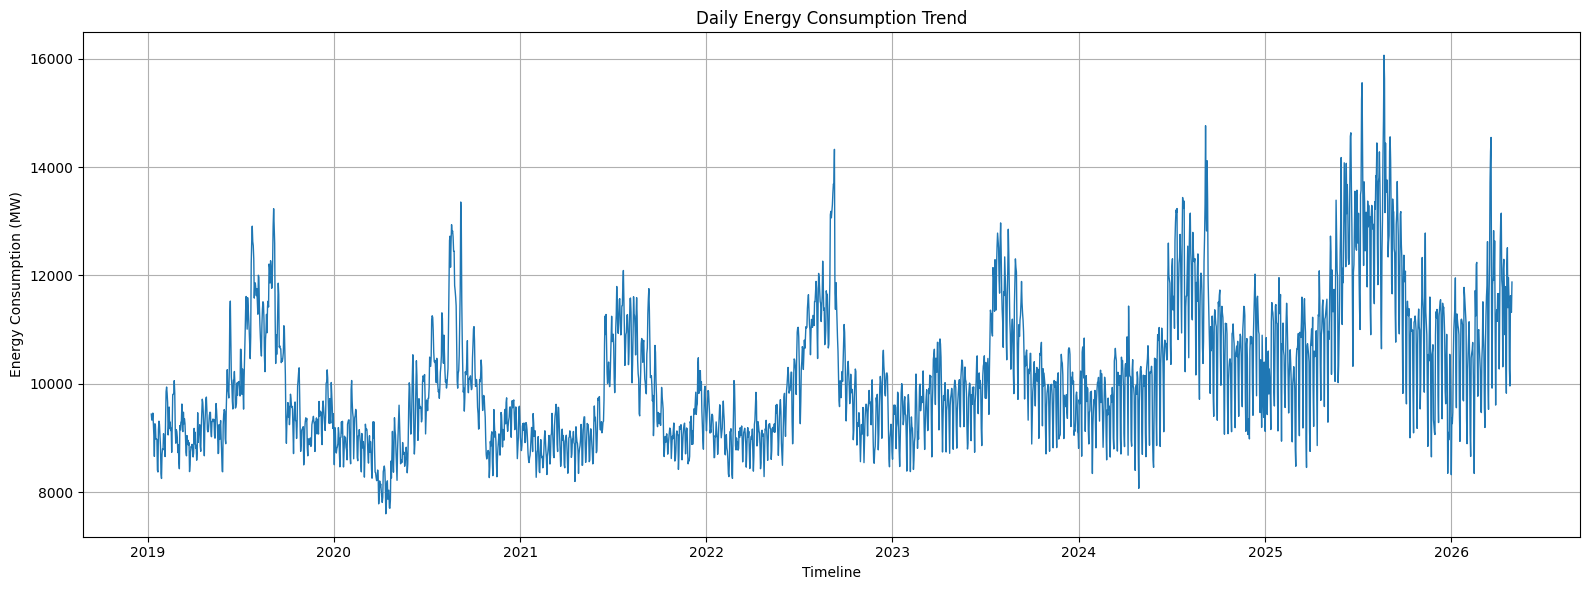

In [180]:
#visulization of Model Performance 
plt.figure(figsize=(16,6))

plt.plot(
    final_df["Date"][::24],
    final_df["California_consumption_MW"][::24],
    linewidth=1
)

plt.title("Daily Energy Consumption Trend")
plt.xlabel("Timeline")
plt.ylabel("Energy Consumption (MW)")
plt.grid(True)

plt.tight_layout()
plt.show()

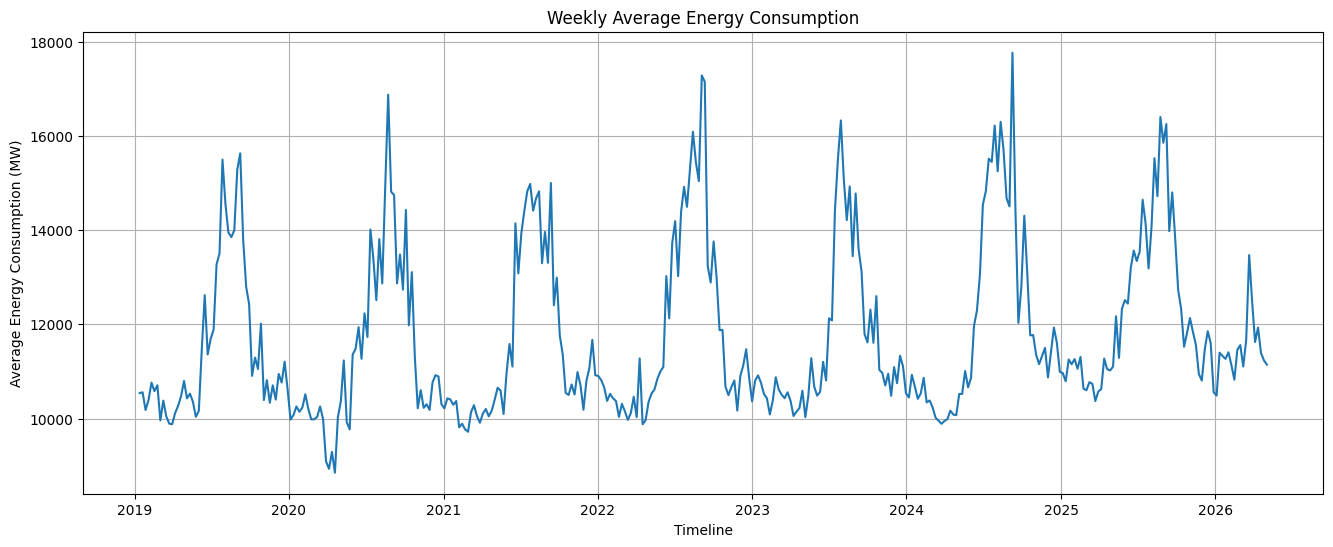

In [181]:
weekly_data = final_df.set_index("Date").resample("W")["California_consumption_MW"].mean()

plt.figure(figsize=(16,6))
plt.plot(weekly_data.index, weekly_data.values)

plt.title("Weekly Average Energy Consumption")
plt.xlabel("Timeline")
plt.ylabel("Average Energy Consumption (MW)")
plt.grid(True)

plt.show()

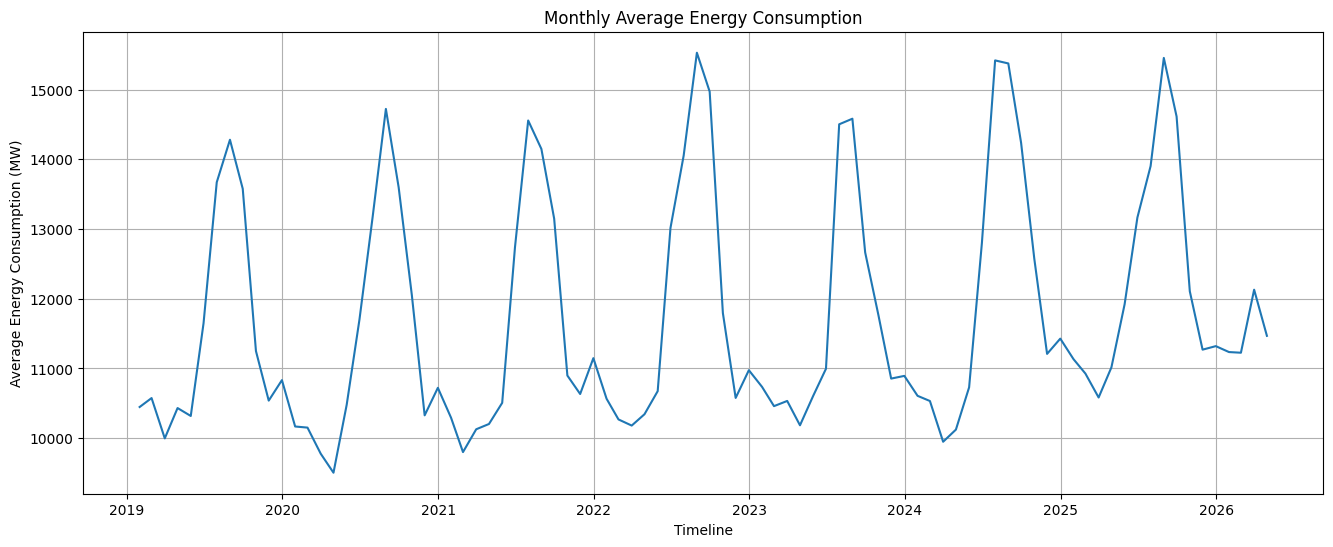

In [182]:
monthly_data = final_df.set_index("Date").resample("ME")["California_consumption_MW"].mean()

plt.figure(figsize=(16,6))
plt.plot(monthly_data.index, monthly_data.values)

plt.title("Monthly Average Energy Consumption")
plt.xlabel("Timeline")
plt.ylabel("Average Energy Consumption (MW)")
plt.grid(True)

plt.show()

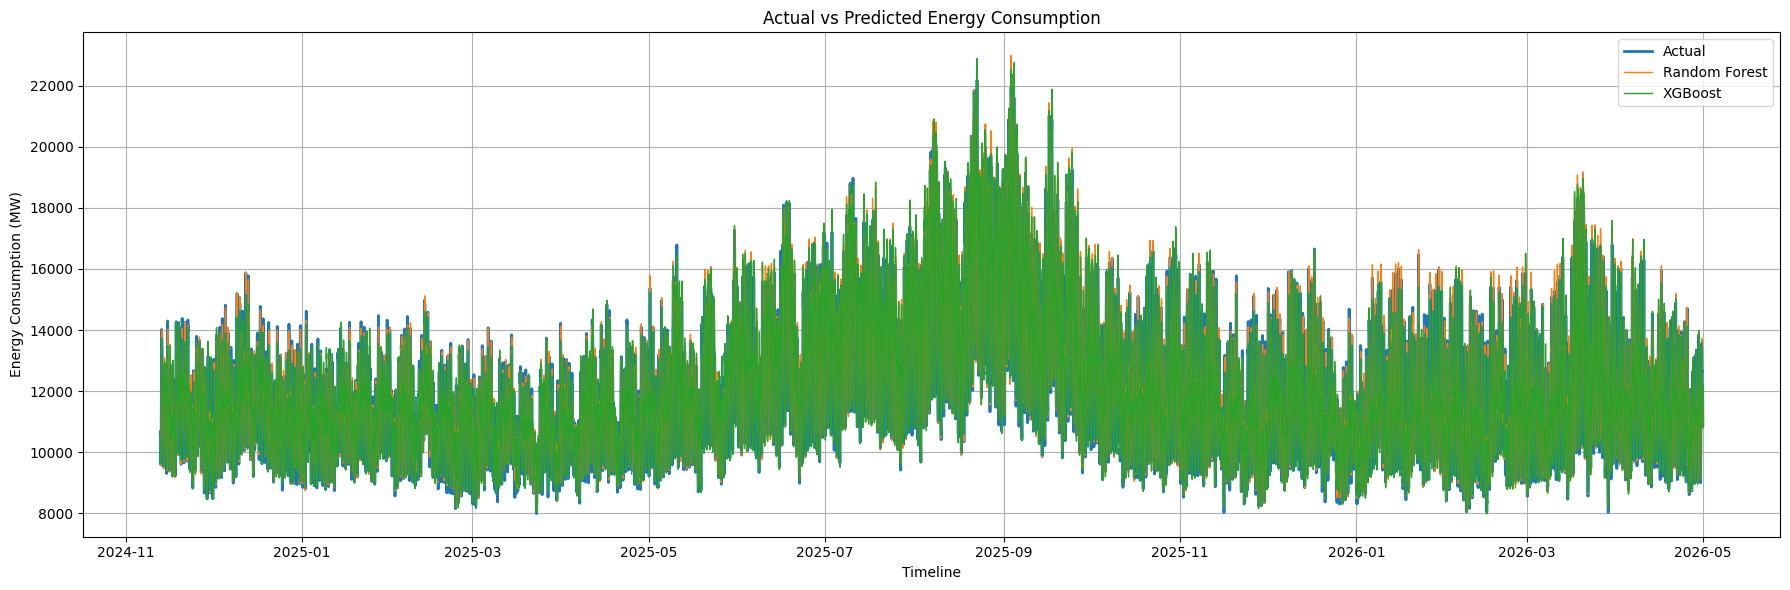

In [183]:

# Test timeline
test_dates = final_df["Date"].iloc[len(x_train):]

plt.figure(figsize=(18,6))

# Actual
plt.plot(test_dates, y_test, label="Actual", linewidth=2)

# Random Forest
plt.plot(test_dates, rf_pred, label="Random Forest", linewidth=1)

# XGBoost
plt.plot(test_dates, xgb_pred, label="XGBoost", linewidth=1)

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Timeline")
plt.ylabel("Energy Consumption (MW)")
plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

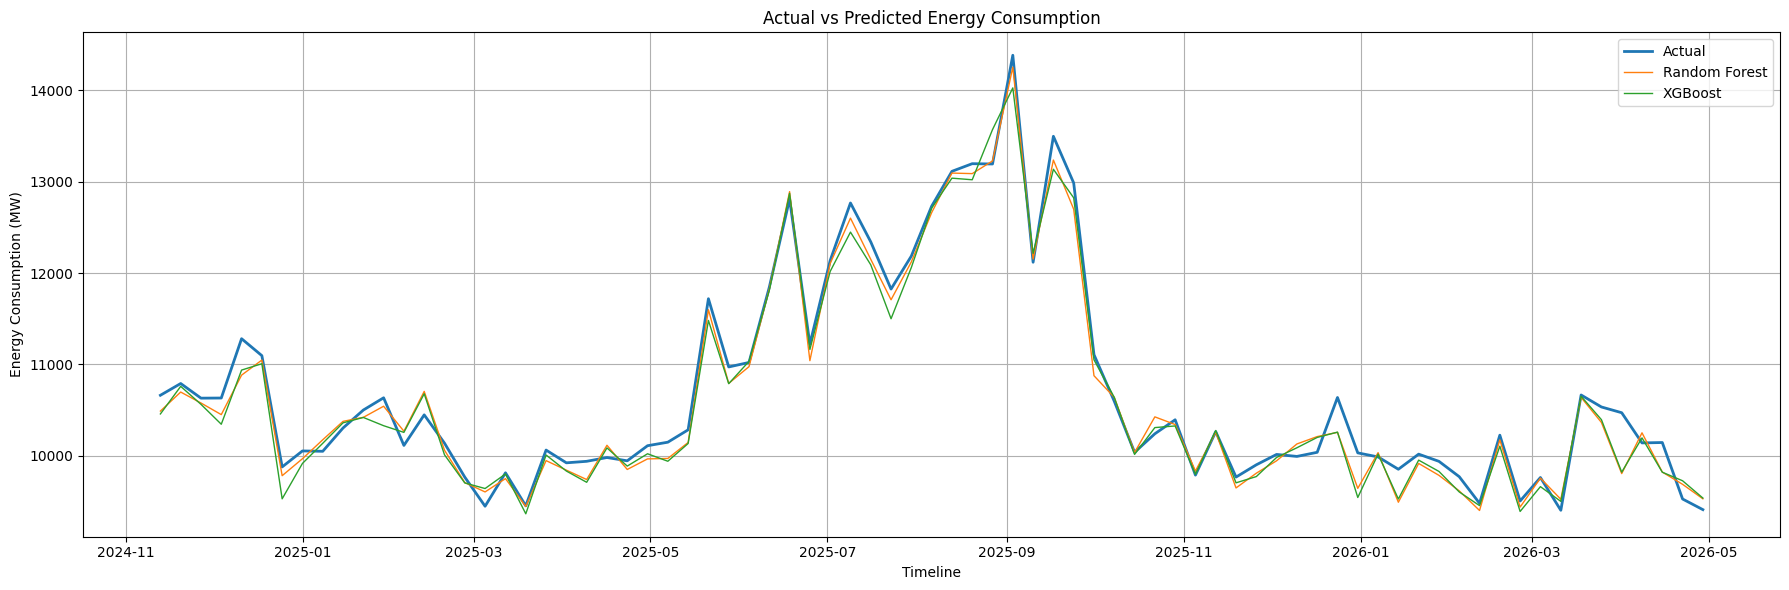

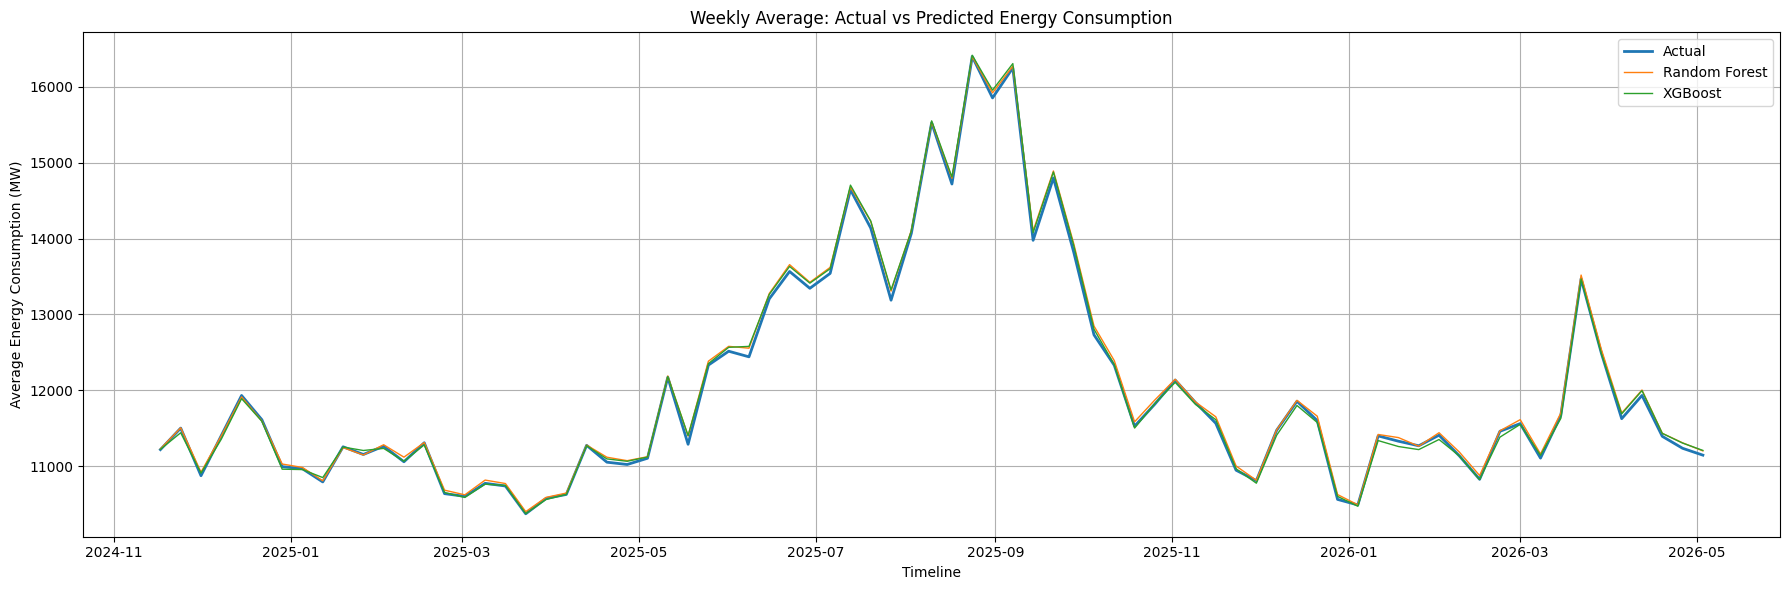

In [184]:
step = 168  # har 24th point (daily)

plt.figure(figsize=(18,6))

plt.plot(test_dates[::step], y_test.iloc[::step], label="Actual", linewidth=2)
plt.plot(test_dates[::step], rf_pred[::step], label="Random Forest", linewidth=1)
plt.plot(test_dates[::step], xgb_pred[::step], label="XGBoost", linewidth=1)

plt.title("Actual vs Predicted Energy Consumption")
plt.xlabel("Timeline")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Date": test_dates.values,
    "Actual": y_test.values,
    "RandomForest": rf_pred,
    "XGBoost": xgb_pred
})

# Set Date as index
comparison_df = comparison_df.set_index("Date")

# Weekly average
weekly_avg = comparison_df.resample("W").mean()

# Plot
plt.figure(figsize=(18,6))

plt.plot(weekly_avg.index, weekly_avg["Actual"], label="Actual", linewidth=2)
plt.plot(weekly_avg.index, weekly_avg["RandomForest"], label="Random Forest", linewidth=1)
plt.plot(weekly_avg.index, weekly_avg["XGBoost"], label="XGBoost", linewidth=1)

plt.title("Weekly Average: Actual vs Predicted Energy Consumption")
plt.xlabel("Timeline")
plt.ylabel("Average Energy Consumption (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [185]:
#Prediction for (may - 5th august2026)
prediction_df = pd.read_excel("./Dataset/new_weather_info.xlsx")
print(prediction_df.shape)
prediction_df.info()

(2328, 3)
<class 'pandas.DataFrame'>
RangeIndex: 2328 entries, 0 to 2327
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2328 non-null   datetime64[us]
 1   Temperature       2328 non-null   float64       
 2   RelativeHumidity  2328 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 54.7 KB


In [186]:
#Create time feature
create_time_features(prediction_df)
prediction_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2328 entries, 0 to 2327
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2328 non-null   datetime64[us]
 1   Temperature       2328 non-null   float64       
 2   RelativeHumidity  2328 non-null   int64         
 3   Hour              2328 non-null   int32         
 4   DayOfWeek         2328 non-null   int32         
 5   Month             2328 non-null   int32         
 6   IsWeekend         2328 non-null   int64         
dtypes: datetime64[us](1), float64(1), int32(3), int64(2)
memory usage: 100.2 KB


In [187]:
#add first lag feature
prediction_df.head()

,Date,Temperature,RelativeHumidity,Hour,DayOfWeek,Month,IsWeekend
0,2026-05-01 00:00:00,22.2,54,0,4,5,0
1,2026-05-01 01:00:00,20.9,57,1,4,5,0
2,2026-05-01 02:00:00,19.1,63,2,4,5,0
3,2026-05-01 03:00:00,17.9,68,3,4,5,0
4,2026-05-01 04:00:00,17.5,71,4,4,5,0


In [188]:
# Prediction column create

def predict(prediction_df, final_df, model):
    prediction_df = prediction_df.reset_index(drop=True)
    prediction_df["California_consumption_MW"] = np.nan

    feature_cols = [
        "Temperature",
        "RelativeHumidity",
        "Lag_1H",
        "Lag_1D",
        "Lag_1W",
        "Hour",
        "DayOfWeek",
        "Month",
        "IsWeekend"
    ]

    for i in range(len(prediction_df)):
        if i == 0:
            prediction_df.loc[i, "Lag_1H"] = final_df["California_consumption_MW"].iloc[-1]
            prediction_df.loc[i, "Lag_1D"] = final_df["California_consumption_MW"].iloc[-24]
            prediction_df.loc[i, "Lag_1W"] = final_df["California_consumption_MW"].iloc[-168]
        else:
            prediction_df.loc[i, "Lag_1H"] = prediction_df.loc[i - 1, "California_consumption_MW"]

            if i < 24:
                prediction_df.loc[i, "Lag_1D"] = final_df["California_consumption_MW"].iloc[-24 + i]
            else:
                prediction_df.loc[i, "Lag_1D"] = prediction_df.loc[i - 24, "California_consumption_MW"]

            if i < 168:
                prediction_df.loc[i, "Lag_1W"] = final_df["California_consumption_MW"].iloc[-168 + i]
            else:
                prediction_df.loc[i, "Lag_1W"] = prediction_df.loc[i - 168, "California_consumption_MW"]

        X = prediction_df.loc[[i], feature_cols]
        pred = model.predict(X)[0]
        prediction_df.loc[i, "California_consumption_MW"] = pred

    return prediction_df

prediction_df = predict(prediction_df, final_df, xgb_model)

print(prediction_df[[
    "California_consumption_MW",
    "Lag_1H",
    "Lag_1D",
    "Lag_1W"
]].head())
   

   California_consumption_MW        Lag_1H        Lag_1D        Lag_1W
0               10290.634766  10875.237150  10262.706590  10317.496430
1                9790.673828  10290.634766   9566.530418   9788.081108
2                9492.189453   9790.673828   9262.275577   9341.519485
3                9283.734375   9492.189453   8994.805392   9237.750971
4                9382.502930   9283.734375   9182.049635   9387.167257


In [189]:
# print(prediction_df[["Date", "California_consumption_MW"]])
prediction_df.tail()

,Date,Temperature,RelativeHumidity,Hour,DayOfWeek,Month,IsWeekend,California_consumption_MW,Lag_1H,Lag_1D,Lag_1W
2323,2026-08-05 19:00:00,28.7,47,19,2,8,0,11767.296875,11747.988281,11669.310547,12266.873047
2324,2026-08-05 20:00:00,30.2,43,20,2,8,0,11666.391602,11767.296875,11387.848633,12038.388672
2325,2026-08-05 21:00:00,31.0,42,21,2,8,0,11260.738281,11666.391602,11085.360352,11667.141602
2326,2026-08-05 22:00:00,30.9,42,22,2,8,0,10518.407227,11260.738281,10564.796875,10932.196289
2327,2026-08-05 23:00:00,30.1,44,23,2,8,0,9945.297852,10518.407227,10062.436523,10358.154297


Text(0, 0.5, 'Predicted Consumption')

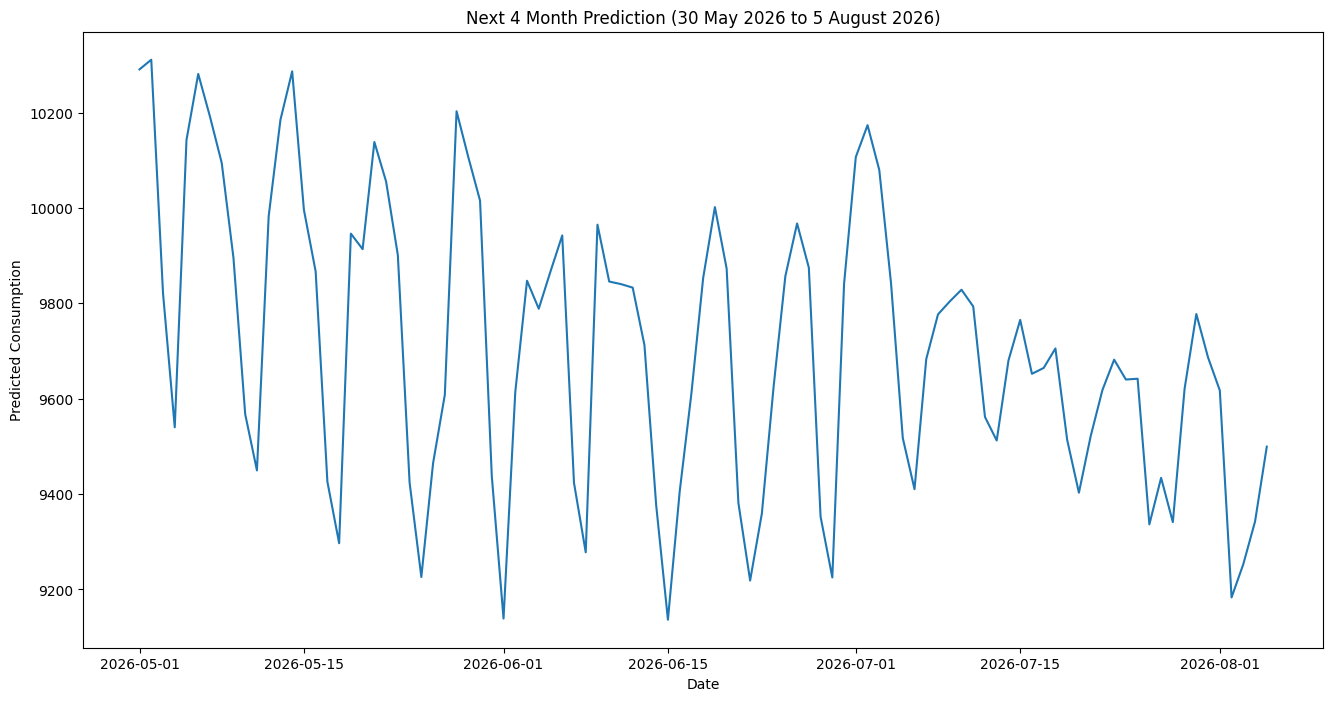

In [190]:
#plot the new prediction
plt.figure(figsize=(16,8))

st = 24

plt.plot(prediction_df["Date"][::st], prediction_df["California_consumption_MW"][::st],linewidth=1.5)
plt.title("Next 4 Month Prediction (30 May 2026 to 5 August 2026)")
plt.xlabel("Date")
plt.ylabel("Predicted Consumption")

In [191]:
#merge predicted data with final_df to calculate future demand

final_df = pd.concat([final_df, prediction_df], ignore_index=True)

final_df.tail()

,Date,California_consumption_MW,Temperature,RelativeHumidity,Lag_1H,Lag_1D,Lag_1W,Hour,DayOfWeek,Month,IsWeekend
66395,2026-08-05 19:00:00,11767.296875,28.7,47,11747.988281,11669.310547,12266.873047,19,2,8,0
66396,2026-08-05 20:00:00,11666.391602,30.2,43,11767.296875,11387.848633,12038.388672,20,2,8,0
66397,2026-08-05 21:00:00,11260.738281,31.0,42,11666.391602,11085.360352,11667.141602,21,2,8,0
66398,2026-08-05 22:00:00,10518.407227,30.9,42,11260.738281,10564.796875,10932.196289,22,2,8,0
66399,2026-08-05 23:00:00,9945.297852,30.1,44,10518.407227,10062.436523,10358.154297,23,2,8,0


In [192]:
import requests
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 34.0522,
    "longitude": -118.2437,
    "start_date": "2026-08-06",
    "end_date": "2026-08-21",
    "hourly": ["temperature_2m", "relative_humidity_2m"],
    "timezone": "America/Los_Angeles",
}

# API Call
response = requests.get(url, params=params)
data = response.json()

future_df = pd.DataFrame(
    {
        "time": data["hourly"]["time"],
        "temperature_C": data["hourly"]["temperature_2m"],
        "humidity_percent": data["hourly"]["relative_humidity_2m"],
    }
)

print(future_df.head())






               time  temperature_C  humidity_percent
0  2026-08-06T00:00           19.7                89
1  2026-08-06T01:00           19.5                90
2  2026-08-06T02:00           18.9                93
3  2026-08-06T03:00           19.0                91
4  2026-08-06T04:00           18.8                91


In [193]:
future_df.rename(
    columns={
        "time": "Date",
        "temperature_C": "Temperature",
        "humidity_percent": "RelativeHumidity"
    },
    inplace=True
)

future_df["Date"] = pd.to_datetime(future_df["Date"])



future_df.head()

,Date,Temperature,RelativeHumidity
0,2026-08-06 00:00:00,19.7,89
1,2026-08-06 01:00:00,19.5,90
2,2026-08-06 02:00:00,18.9,93
3,2026-08-06 03:00:00,19.0,91
4,2026-08-06 04:00:00,18.8,91


In [194]:
create_time_features(future_df)
future_df = predict(future_df, final_df, xgb_model)
future_df.head()
# Notebook me predictions nikalne ke baad future_df ko save kar lein



,Date,Temperature,RelativeHumidity,Hour,DayOfWeek,Month,IsWeekend,California_consumption_MW,Lag_1H,Lag_1D,Lag_1W
0,2026-08-06 00:00:00,19.7,89,0,3,8,0,9442.611328,9945.297852,9499.477539,9777.559570
1,2026-08-06 01:00:00,19.5,90,1,3,8,0,9077.450195,9442.611328,9086.487305,9265.138672
2,2026-08-06 02:00:00,18.9,93,2,3,8,0,8678.832031,9077.450195,8910.193359,9012.083008
3,2026-08-06 03:00:00,19.0,91,3,3,8,0,8564.615234,8678.832031,8745.008789,8903.351562
4,2026-08-06 04:00:00,18.8,91,4,3,8,0,8676.012695,8564.615234,8912.693359,9059.351562


In [195]:
print(
    future_df[[
        "Date",
        "California_consumption_MW",
        "Lag_1H",
        "Lag_1D",
        "Lag_1W",
    ]].head()
)

                 Date  California_consumption_MW       Lag_1H       Lag_1D  \
0 2026-08-06 00:00:00                9442.611328  9945.297852  9499.477539   
1 2026-08-06 01:00:00                9077.450195  9442.611328  9086.487305   
2 2026-08-06 02:00:00                8678.832031  9077.450195  8910.193359   
3 2026-08-06 03:00:00                8564.615234  8678.832031  8745.008789   
4 2026-08-06 04:00:00                8676.012695  8564.615234  8912.693359   

        Lag_1W  
0  9777.559570  
1  9265.138672  
2  9012.083008  
3  8903.351562  
4  9059.351562  


In [196]:
future_df.to_csv("future_predictions.csv", index=False)
print("future_df successfully saved to future_predictions.csv")

future_df successfully saved to future_predictions.csv


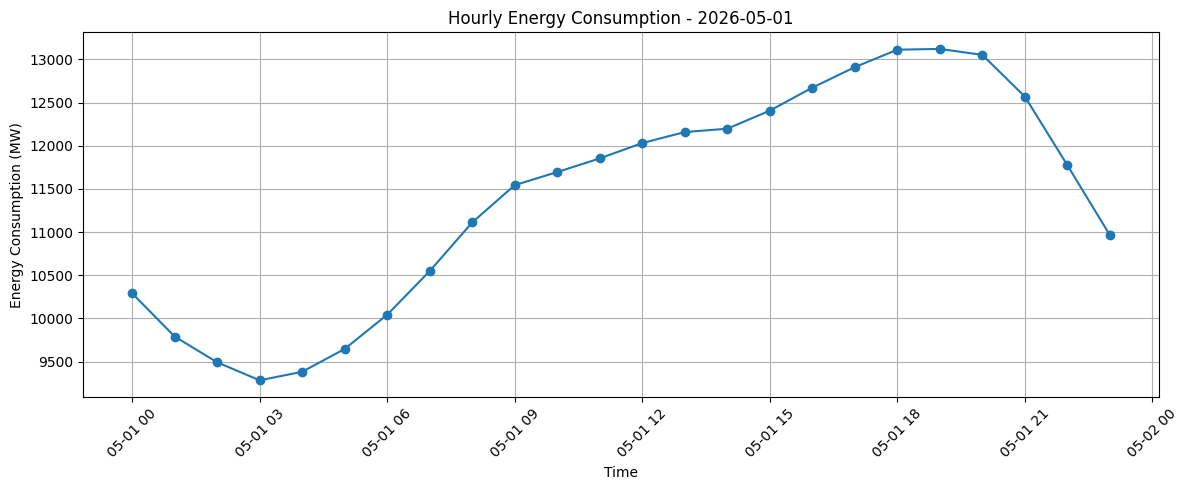

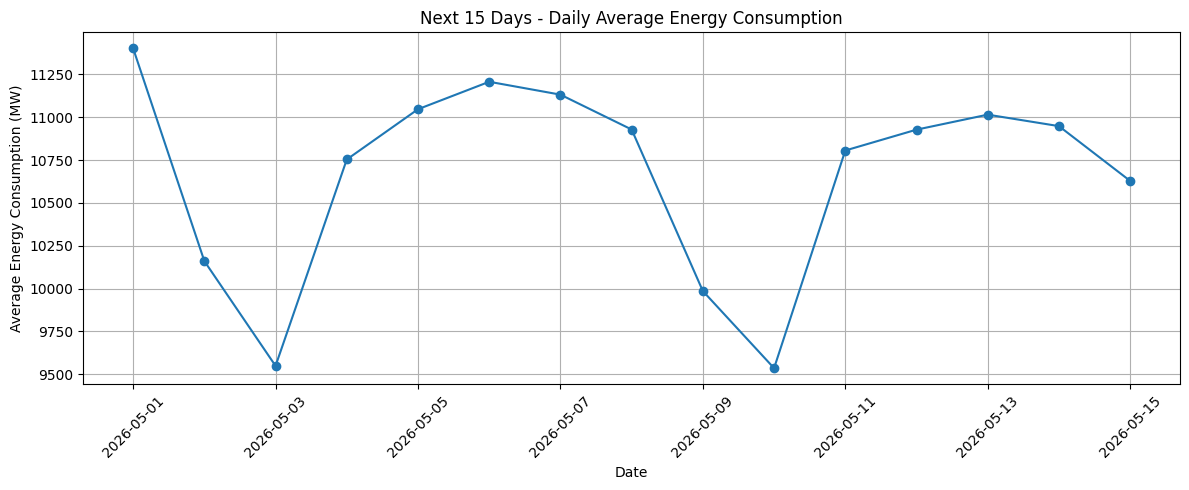

In [197]:


prediction_df["Date"] = pd.to_datetime(prediction_df["Date"])

current_date = prediction_df["Date"].dt.date.min()

today_df = prediction_df[
    prediction_df["Date"].dt.date == current_date
].copy()

daily_df = (
    prediction_df
    .assign(DateOnly=prediction_df["Date"].dt.date)
    .groupby("DateOnly")["California_consumption_MW"]
    .mean()
    .reset_index()
)

daily_df = daily_df.head(15)

plt.figure(figsize=(12, 5))
plt.plot(
    today_df["Date"],
    today_df["California_consumption_MW"],
    marker="o"
)
plt.title(f"Hourly Energy Consumption - {current_date}")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (MW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(
    daily_df["DateOnly"],
    daily_df["California_consumption_MW"],
    marker="o"
)
plt.title("Next 15 Days - Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Average Energy Consumption (MW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [198]:
import joblib

# Save the trained model to disk
joblib.dump(xgb_model, "model.pkl")  # Replace 'model' with your model object name (e.g., rf_model or xgb_model)
print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl
